# 🚚 Delivery Analytics: Understanding Delays, Cost & Customer Satisfaction

## Project Overview
This project analyzes 25,000 delivery records to answer three business questions:
1. **What drives delivery delays and failures?**
2. **What determines delivery cost?**
3. **Can we predict at-risk deliveries in advance?**

**Dataset:** 25,000 rows × 15 columns covering delivery partners, package details, 
weather conditions, cost, timing, and customer ratings.

**Tools used:** Python, Pandas, Matplotlib, Seaborn, Scikit-learn

## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import r2_score, mean_absolute_error, accuracy_score, classification_report, confusion_matrix
from scipy.stats import chi2_contingency

df = pd.read_csv(r"C:\Users\shahul\Downloads\logistic_analytics.zip")
df.head()

,delivery_id,delivery_partner,package_type,vehicle_type,delivery_mode,region,weather_condition,distance_km,package_weight_kg,delivery_time_hours,expected_time_hours,delayed,delivery_status,delivery_rating,delivery_cost
0,250.99,delhivery,automobile parts,bike,same day,west,clear,297.0,46.96,1970-01-01 00:00:00.000000008,1970-01-01 00:00:00.000000008,no,delivered,3,1632.7206
1,250.99,xpressbees,cosmetics,ev van,express,central,cold,89.6,47.39,1970-01-01 00:00:00.000000002,1970-01-01 00:00:00.000000003,no,delivered,5,640.1700
2,250.99,shadowfax,groceries,truck,two day,east,rainy,273.5,26.89,1970-01-01 00:00:00.000000010,1970-01-01 00:00:00.000000016,no,delivered,4,1448.1700
3,250.99,dhl,electronics,ev van,same day,east,cold,269.7,12.69,1970-01-01 00:00:00.000000006,1970-01-01 00:00:00.000000008,no,delivered,3,1486.5700
4,250.99,dhl,clothing,van,two day,north,foggy,256.7,37.02,1970-01-01 00:00:00.000000009,1970-01-01 00:00:00.000000016,no,delivered,4,1394.5600


# Initial Exploration of data

In [2]:
print(df.isnull().sum())
print(df.shape)

delivery_id            0
delivery_partner       0
package_type           0
vehicle_type           0
delivery_mode          0
region                 0
weather_condition      0
distance_km            0
package_weight_kg      0
delivery_time_hours    0
expected_time_hours    0
delayed                0
delivery_status        0
delivery_rating        0
delivery_cost          0
dtype: int64
(25000, 15)


In [3]:
df.describe(include = 'all')

,delivery_id,delivery_partner,package_type,vehicle_type,delivery_mode,region,weather_condition,distance_km,package_weight_kg,delivery_time_hours,expected_time_hours,delayed,delivery_status,delivery_rating,delivery_cost
count,25000.000000,25000,25000,25000,25000,25000,25000,25000.000000,25000.000000,25000,25000,25000,25000,25000.000000,25000.000000
unique,NaN,9,9,6,4,5,6,NaN,NaN,20,9,2,3,NaN,NaN
top,NaN,xpressbees,fragile items,ev bike,two day,west,foggy,NaN,NaN,1970-01-01 00:00:00.000000006,1970-01-01 00:00:00.000000016,no,delivered,NaN,NaN
freq,NaN,2826,2848,4218,6302,5095,4219,NaN,NaN,3118,6302,18331,18331,NaN,NaN
mean,12500.500000,NaN,NaN,NaN,NaN,NaN,NaN,150.390436,25.145898,NaN,NaN,NaN,NaN,3.666000,864.944579
std,7212.732314,NaN,NaN,NaN,NaN,NaN,NaN,86.409745,14.368663,NaN,NaN,NaN,NaN,1.149964,435.712593
min,250.990000,NaN,NaN,NaN,NaN,NaN,NaN,3.600000,0.670000,NaN,NaN,NaN,NaN,1.000000,95.667400
25%,6250.750000,NaN,NaN,NaN,NaN,NaN,NaN,75.900000,12.680000,NaN,NaN,NaN,NaN,3.000000,490.800000
50%,12500.500000,NaN,NaN,NaN,NaN,NaN,NaN,151.000000,25.145000,NaN,NaN,NaN,NaN,4.000000,867.535000
75%,18750.250000,NaN,NaN,NaN,NaN,NaN,NaN,224.900000,37.660000,NaN,NaN,NaN,NaN,5.000000,1237.910000


# 2. Data Cleaning

In [4]:
def fix_fake_timestamp(col):
    dt = pd.to_datetime(col)
    return dt.view('int64')

df['delivery_time_hours'] = fix_fake_timestamp(df['delivery_time_hours'])
df['expected_time_hours'] = fix_fake_timestamp(df['expected_time_hours'])

df[['delivery_time_hours', 'expected_time_hours']].describe()

C:\Users\shahul\AppData\Local\Temp\ipykernel_17016\3497018071.py:3: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  return dt.view('int64')
C:\Users\shahul\AppData\Local\Temp\ipykernel_17016\3497018071.py:3: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  return dt.view('int64')


,delivery_time_hours,expected_time_hours
count,25000.000000,25000.000000
mean,6.248040,13.107680
std,3.140935,7.559024
min,0.000000,2.000000
25%,4.000000,8.000000
50%,6.000000,8.000000
75%,8.000000,16.000000
max,19.000000,24.000000


### Checking for a redundant / related column pair
delayed (yes/no) and delivery_status (3 categories) looked related. A crosstab 
confirms delivery_status actually splits "yes" into two distinct outcomes: delayed 
and failed. This distinction matters — a late package and a lost package are very 
different business problems.

In [5]:
pd.crosstab(df['delayed'], df['delivery_status'])

delivery_status,delayed,delivered,failed
delayed,,,
no,0,18331,0
yes,5341,0,1328


In [6]:
#data integrity checkprint
(df['delivery_id'].nunique(), "unique IDs out of", len(df), "rows")
print(df['delivery_id'].duplicated().sum(), "duplicate IDs")

498 duplicate IDs


## 3. Feature Engineering

In [7]:
df['time_gap_hours'] = df['expected_time_hours'] - df['delivery_time_hours']
df['cost_per_km'] = df['delivery_cost'] / df['distance_km']
df['cost_per_kg'] = df['delivery_cost'] / df['package_weight_kg']

df[['time_gap_hours', 'cost_per_km', 'cost_per_kg']].describe()

,time_gap_hours,cost_per_km,cost_per_kg
count,25000.000000,25000.000000,25000.000000
mean,6.859640,7.041301,81.742858
std,8.069482,5.004036,182.327259
min,-12.000000,5.002579,3.104515
25%,0.000000,5.420741,19.686678
50%,6.000000,5.744712,34.272263
75%,14.000000,6.494886,65.230630
max,24.000000,73.491667,2344.626866


### 4. Exploratory Data Analysis

In [8]:
print("Overall outcome distribution (%):")
print(df['delivery_status'].value_counts(normalize=True) * 100)

print("\nBy delivery partner (%):")
print((pd.crosstab(df['delivery_partner'], df['delivery_status'], normalize='index') * 100).round(1))

print("\nBy weather condition (%):")
print((pd.crosstab(df['weather_condition'], df['delivery_status'], normalize='index') * 100).round(1))

print("\nBy vehicle type (%):")
print((pd.crosstab(df['vehicle_type'], df['delivery_status'], normalize='index') * 100).round(1))

print("\nBy region (%):")
print((pd.crosstab(df['region'], df['delivery_status'], normalize='index') * 100).round(1))

Overall outcome distribution (%):
delivery_status
delivered    73.324
delayed      21.364
failed        5.312
Name: proportion, dtype: float64

By delivery partner (%):
delivery_status   delayed  delivered  failed
delivery_partner                            
amazon logistics     21.6       72.8     5.6
blue dart            21.2       73.1     5.8
delhivery            19.8       75.2     5.0
dhl                  20.4       73.7     5.9
ecom express         22.2       73.4     4.4
ekart                21.9       72.6     5.5
fedex                20.4       74.8     4.8
shadowfax            22.4       72.7     4.9
xpressbees           22.4       71.7     5.9

By weather condition (%):
delivery_status    delayed  delivered  failed
weather_condition                            
clear                 14.3       82.6     3.2
cold                  12.9       84.0     3.2
foggy                 24.4       69.7     5.9
hot                   13.9       82.9     3.2
rainy                 30.0       

### Statistical significance testing

A chi-square test checks whether two categorical variables are genuinely related, 
or whether an observed difference could just be random noise. A p-value below 0.05 
suggests the relationship is unlikely to be chance.

**Important distinction:** with a large sample (25,000 rows), even tiny, practically 
meaningless differences can appear "statistically significant." We check both the 
p-value *and* the size of the effect before drawing conclusions.

In [9]:
# Weather vs delivery outcome
contingency = pd.crosstab(df['weather_condition'], df['delivery_status'])
chi2, p_value, dof, expected = chi2_contingency(contingency)
print(f"Weather -> Outcome:  chi2={chi2:.2f}, p-value={p_value:.10f}")

Weather -> Outcome:  chi2=1359.97, p-value=0.0000000000


In [10]:
# Partner vs delivery outcome
contingency2 = pd.crosstab(df['delivery_partner'], df['delivery_status'])
chi2b, p_value2, dof2, expected2 = chi2_contingency(contingency2)
print(f"Partner -> Outcome:  chi2={chi2b:.2f}, p-value={p_value2:.10f}")

Partner -> Outcome:  chi2=26.80, p-value=0.0438128624


**Finding:** Weather shows an extremely strong, significant relationship with delivery 
outcome (p ≈ 0). Delivery partner is technically significant (p = 0.044) but the effect 
size is tiny (all partners cluster within a 3-point delay-rate band) — a textbook case 
of statistical significance without practical significance.

## 5. Visualizations

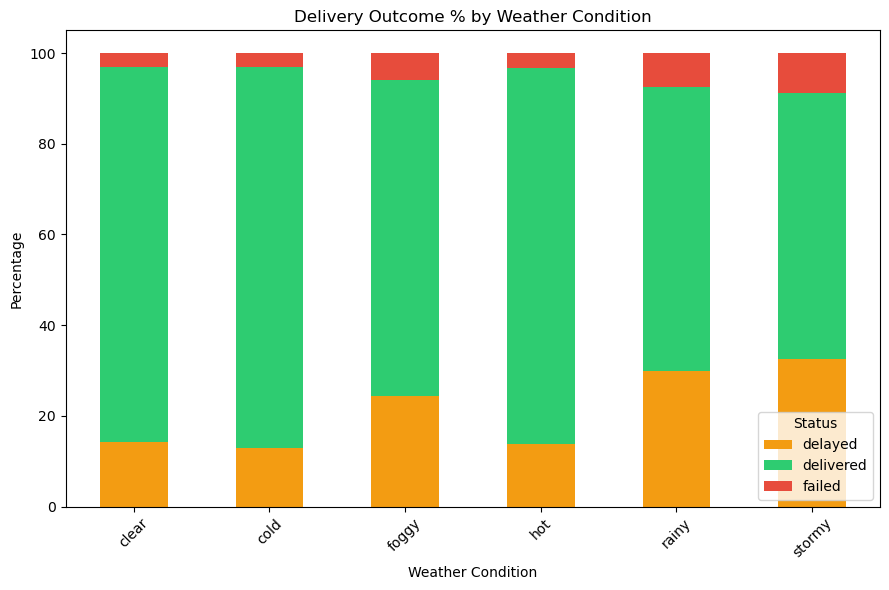

In [11]:
weather_ct = pd.crosstab(df['weather_condition'], df['delivery_status'], normalize='index') * 100

weather_ct.plot(kind='bar', stacked=True, figsize=(9,6), color=['#f39c12','#2ecc71','#e74c3c'])
plt.title('Delivery Outcome % by Weather Condition')
plt.xlabel('Weather Condition')
plt.ylabel('Percentage')
plt.legend(title='Status')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

C:\Users\shahul\AppData\Local\Temp\ipykernel_17016\1384011432.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='delivery_status', order=['delivered','delayed','failed'],


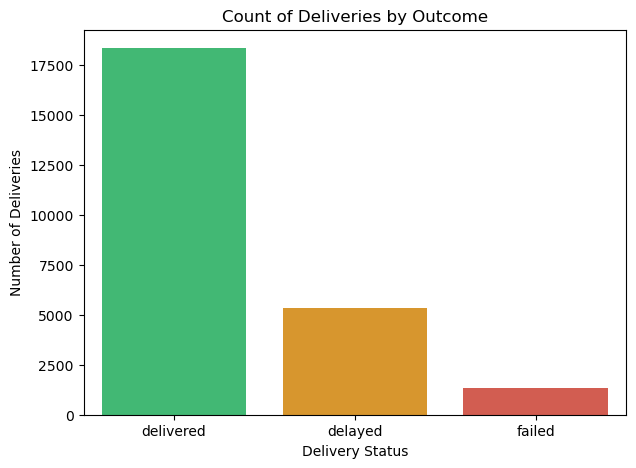

In [12]:
plt.figure(figsize=(7,5))
sns.countplot(data=df, x='delivery_status', order=['delivered','delayed','failed'],
              palette=['#2ecc71','#f39c12','#e74c3c'])
plt.title('Count of Deliveries by Outcome')
plt.xlabel('Delivery Status')
plt.ylabel('Number of Deliveries')
plt.show()

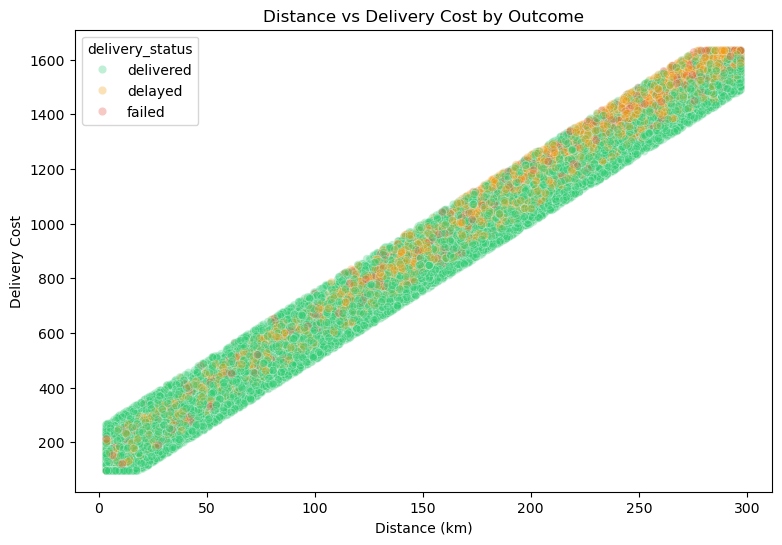

In [13]:
plt.figure(figsize=(9,6))
sns.scatterplot(data=df, x='distance_km', y='delivery_cost', hue='delivery_status',
                 alpha=0.3, palette=['#2ecc71','#f39c12','#e74c3c'])
plt.title('Distance vs Delivery Cost by Outcome')
plt.xlabel('Distance (km)')
plt.ylabel('Delivery Cost')
plt.show()

C:\Users\shahul\AppData\Local\Temp\ipykernel_17016\239690699.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='delivery_status', y='delivery_rating', order=['delivered','delayed','failed'],


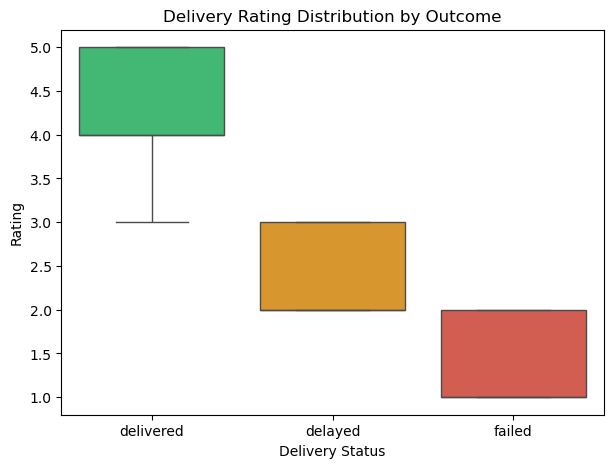

In [14]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x='delivery_status', y='delivery_rating', order=['delivered','delayed','failed'],
            palette=['#2ecc71','#f39c12','#e74c3c'])
plt.title('Delivery Rating Distribution by Outcome')
plt.xlabel('Delivery Status')
plt.ylabel('Rating')
plt.show()

C:\Users\shahul\AppData\Local\Temp\ipykernel_17016\2102923310.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=partner_delay.values, y=partner_delay.index, palette='Reds_r')


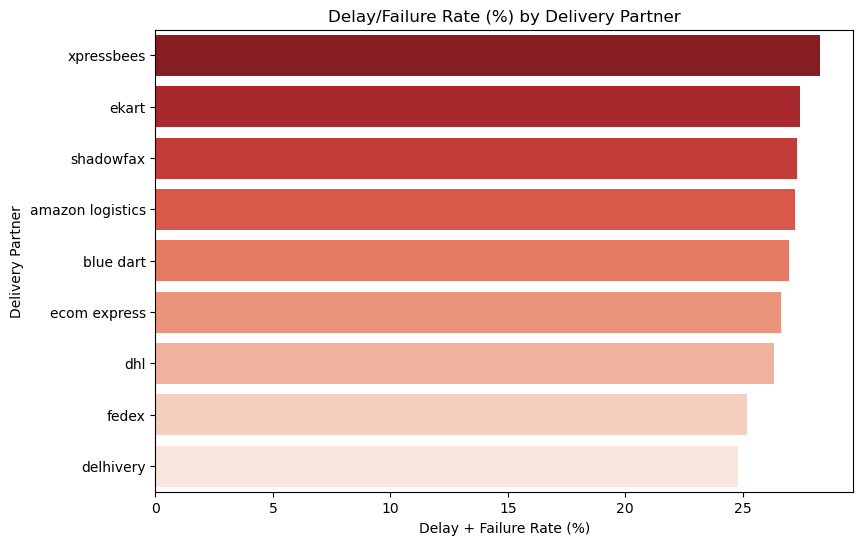

In [15]:
partner_delay = (df[df['delivery_status'] != 'delivered'].groupby('delivery_partner').size()
                  / df.groupby('delivery_partner').size() * 100).sort_values(ascending=False)

plt.figure(figsize=(9,6))
sns.barplot(x=partner_delay.values, y=partner_delay.index, palette='Reds_r')
plt.title('Delay/Failure Rate (%) by Delivery Partner')
plt.xlabel('Delay + Failure Rate (%)')
plt.ylabel('Delivery Partner')
plt.show()

**Key visual findings:**
- Stormy/rainy weather roughly **doubles** the delay rate and **triples** the failure 
  rate compared to clear conditions
- Distance and cost follow a near-perfect straight-line relationship
- Customer ratings drop sharply and consistently as outcomes worsen (delivered → 
  delayed → failed), with almost no overlap between groups
- All delivery partners cluster within a ~3-point delay-rate band — no partner stands 
  out as meaningfully better or worse

## 6. Predictive Modeling — Cost Regression

**Goal:** Quantify the relationship between distance/weight and delivery cost.


In [16]:
X = df[['distance_km', 'package_weight_kg']]
y = df['delivery_cost']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred = lr_model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"R² score: {r2:.4f}")
print(f"Mean Absolute Error: ₹{mae:.2f}")
print(f"Coefficients: distance_km={lr_model.coef_[0]:.3f}, package_weight_kg={lr_model.coef_[1]:.3f}")
print(f"Intercept: {lr_model.intercept_:.3f}")

R² score: 0.9910
Mean Absolute Error: ₹37.14
Coefficients: distance_km=4.996, package_weight_kg=2.958
Intercept: 39.173


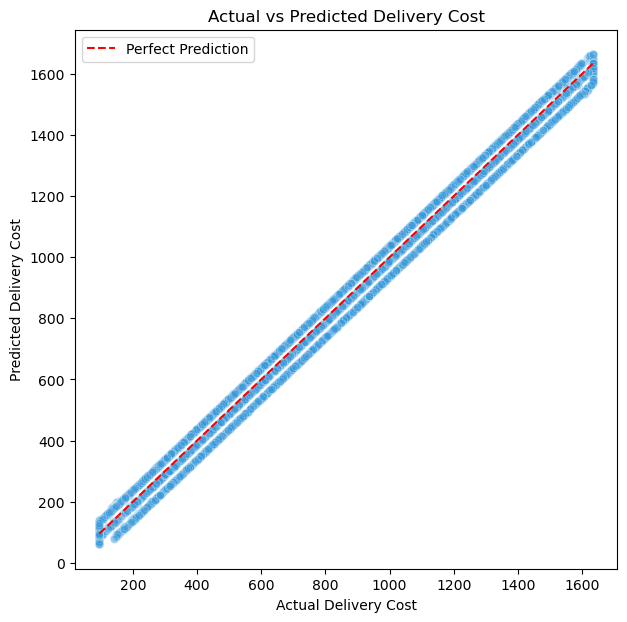

In [17]:
plt.figure(figsize=(7,7))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.3, color='#3498db')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect Prediction')
plt.xlabel('Actual Delivery Cost')
plt.ylabel('Predicted Delivery Cost')
plt.title('Actual vs Predicted Delivery Cost')
plt.legend()
plt.show()

**Result:** R² = 0.991 — distance and weight explain 99.1% of the variation in cost. 
The model recovers a clear pricing formula:

 delivery_cost ≈ ₹39 (base fee) + ₹5/km + ₹3/kg

## 7. Predictive Modeling — Delay/Failure Classification

**Goal:** Predict delivery_status (delivered / delayed / failed) using pre-delivery 
information — weather, distance, weight, region, vehicle type.


In [18]:
features = df[['weather_condition', 'distance_km', 'package_weight_kg', 'region', 'vehicle_type']]
features_encoded = pd.get_dummies(features, columns=['weather_condition', 'region', 'vehicle_type'], drop_first=True)
target = df['delivery_status']

X_train, X_test, y_train, y_test = train_test_split(
    features_encoded, target, test_size=0.2, random_state=42, stratify=target
)

# Baseline model (no class balancing)
tree_model = DecisionTreeClassifier(max_depth=5, random_state=42)
tree_model.fit(X_train, y_train)
y_pred = tree_model.predict(X_test)

print("Baseline Accuracy:", accuracy_score(y_test, y_pred))
print("\nBaseline Classification Report:\n", classification_report(y_test, y_pred))

Baseline Accuracy: 0.7324

Baseline Classification Report:
               precision    recall  f1-score   support

     delayed       0.44      0.04      0.07      1068
   delivered       0.74      0.99      0.84      3666
      failed       0.00      0.00      0.00       266

    accuracy                           0.73      5000
   macro avg       0.39      0.34      0.30      5000
weighted avg       0.63      0.73      0.63      5000



C:\Users\shahul\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\shahul\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\shahul\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


### The class imbalance problem

The baseline model reaches 73% accuracy but with **near-zero recall on "delayed" and 
"failed"** classes. Since 73% of deliveries are simply "delivered," the model learned 
to lazily predict the majority class almost every time — a common trap when classes are 
imbalanced. This model provides no real business value, since its entire purpose was to 
flag *at-risk* deliveries.

In [19]:
tree_model_balanced = DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42)
tree_model_balanced.fit(X_train, y_train)
y_pred_balanced = tree_model_balanced.predict(X_test)

print("Balanced Accuracy:", accuracy_score(y_test, y_pred_balanced))
print("\nBalanced Classification Report:\n", classification_report(y_test, y_pred_balanced))

Balanced Accuracy: 0.5394

Balanced Classification Report:
               precision    recall  f1-score   support

     delayed       0.34      0.33      0.33      1068
   delivered       0.83      0.62      0.71      3666
      failed       0.07      0.31      0.11       266

    accuracy                           0.54      5000
   macro avg       0.41      0.42      0.38      5000
weighted avg       0.68      0.54      0.60      5000



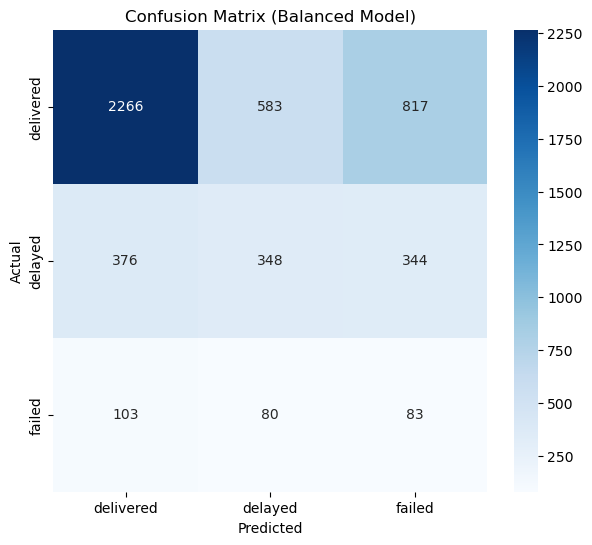

In [20]:
cm = confusion_matrix(y_test, y_pred_balanced, labels=['delivered','delayed','failed'])
plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['delivered','delayed','failed'],
            yticklabels=['delivered','delayed','failed'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Balanced Model)')
plt.show()

C:\Users\shahul\AppData\Local\Temp\ipykernel_17016\4245278727.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette='viridis')


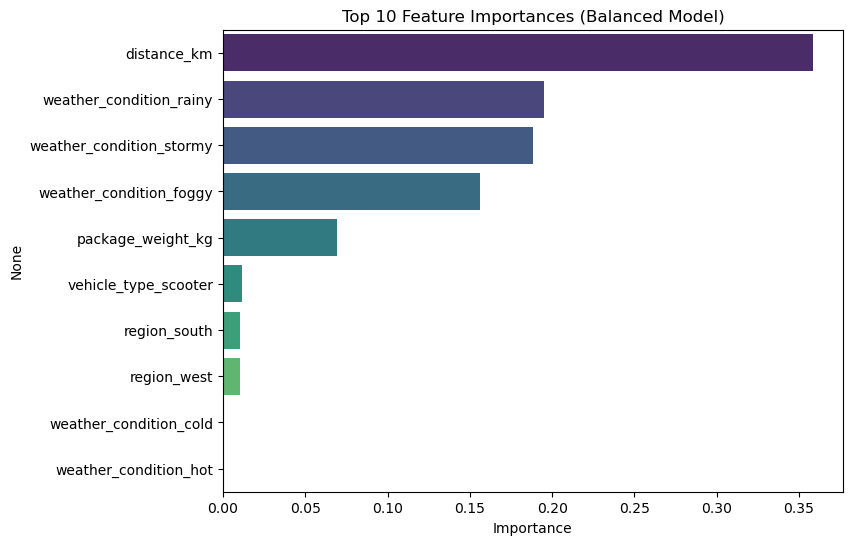

In [21]:
importances = pd.Series(tree_model_balanced.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False).head(10)

plt.figure(figsize=(8,6))
sns.barplot(x=importances.values, y=importances.index, palette='viridis')
plt.title('Top 10 Feature Importances (Balanced Model)')
plt.xlabel('Importance')
plt.show()